In [39]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

import kagglehub

path = kagglehub.dataset_download("feyzazkefe/trashnet")
dataset_dir = path + "/dataset-resized"

print("Dataset path:", dataset_dir)
print("Classes:", os.listdir(dataset_dir))

Dataset path: /home/norah/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized
Classes: ['glass', 'metal', 'cardboard', 'paper', 'plastic', 'trash']


In [40]:
total_images = 0
class_counts = {}

for cls in os.listdir(dataset_dir):
    cls_path = os.path.join(dataset_dir, cls)
    
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        class_counts[cls] = count
        total_images += count

print("Number of images per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print("\nTotal images:", total_images)

Number of images per class:
glass: 501
metal: 410
cardboard: 403
paper: 594
plastic: 482
trash: 137

Total images: 2527


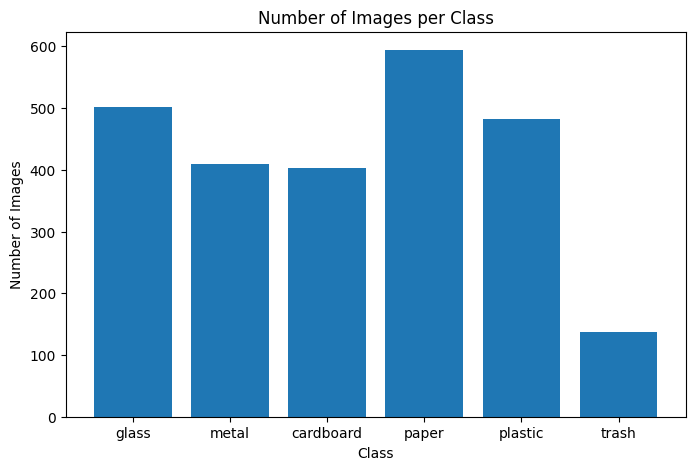

In [41]:
plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [42]:
for cls in os.listdir(dataset_dir):
    cls_path = os.path.join(dataset_dir, cls)

    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)

    print(f"{cls}: {img.size}")

glass: (512, 384)
metal: (512, 384)
cardboard: (512, 384)
paper: (512, 384)
plastic: (512, 384)
trash: (512, 384)


In [43]:
widths = []
heights = []
image_sizes = {}

for cls in os.listdir(dataset_dir):
    cls_path = os.path.join(dataset_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)
            w, h = img.size

            widths.append(w)
            heights.append(h)

            image_sizes[(w, h)] = image_sizes.get((w, h), 0) + 1

        except:
            pass


print("\nNumber of unique image sizes:", len(image_sizes))


Number of unique image sizes: 1


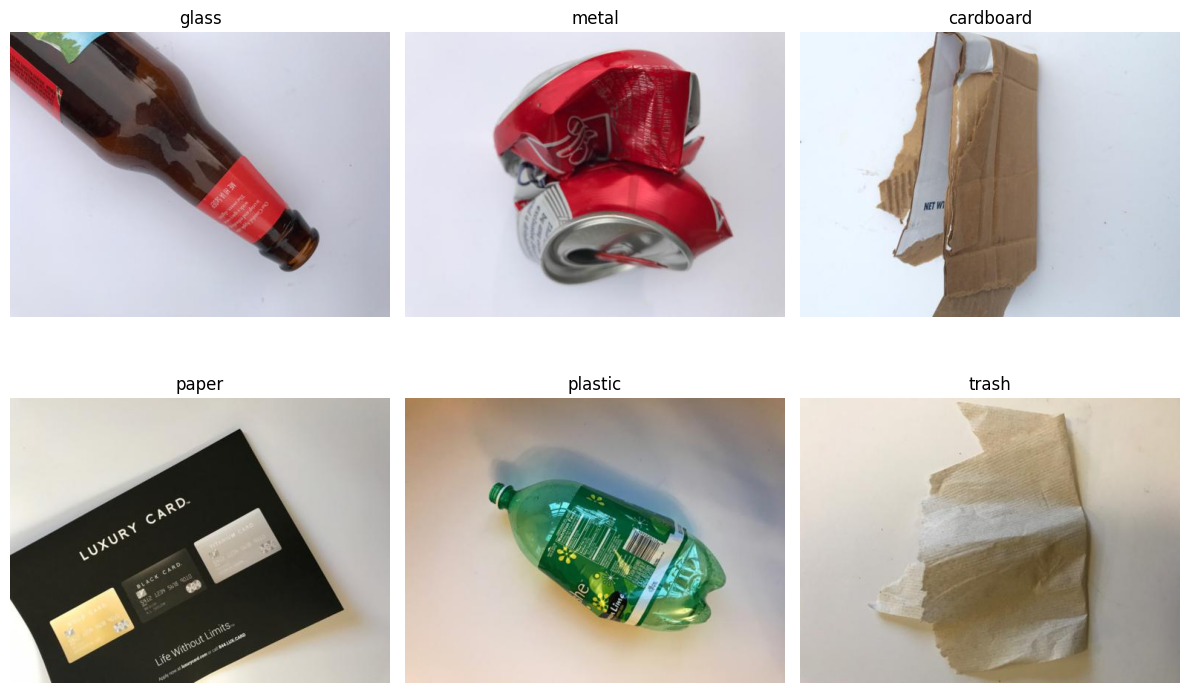

In [44]:
# ============================================================
# 5. VISUALIZE SAMPLE IMAGES
# ============================================================

classes = list(class_counts.keys())

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# 6. IMAGE PROCESSING: SEGMENTATION FUNCTION
# Otsu Thresholding + Morphological Operations + Largest Contour
# ============================================================

def apply_segmentation_largest_contour(img):
    # Resize image
    img = cv2.resize(img, (224, 224))

    # Convert RGB to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Blur to reduce small noise
    gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu Thresholding
    _, mask = cv2.threshold(
        gray_blur,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Morphological cleaning
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Find contours
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return img

    # Keep largest contour only
    largest_contour = max(contours, key=cv2.contourArea)

    clean_mask = np.zeros_like(mask)
    cv2.drawContours(
        clean_mask,
        [largest_contour],
        -1,
        255,
        thickness=cv2.FILLED
    )

    # Apply mask
    segmented = cv2.bitwise_and(img, img, mask=clean_mask)

    return segmented

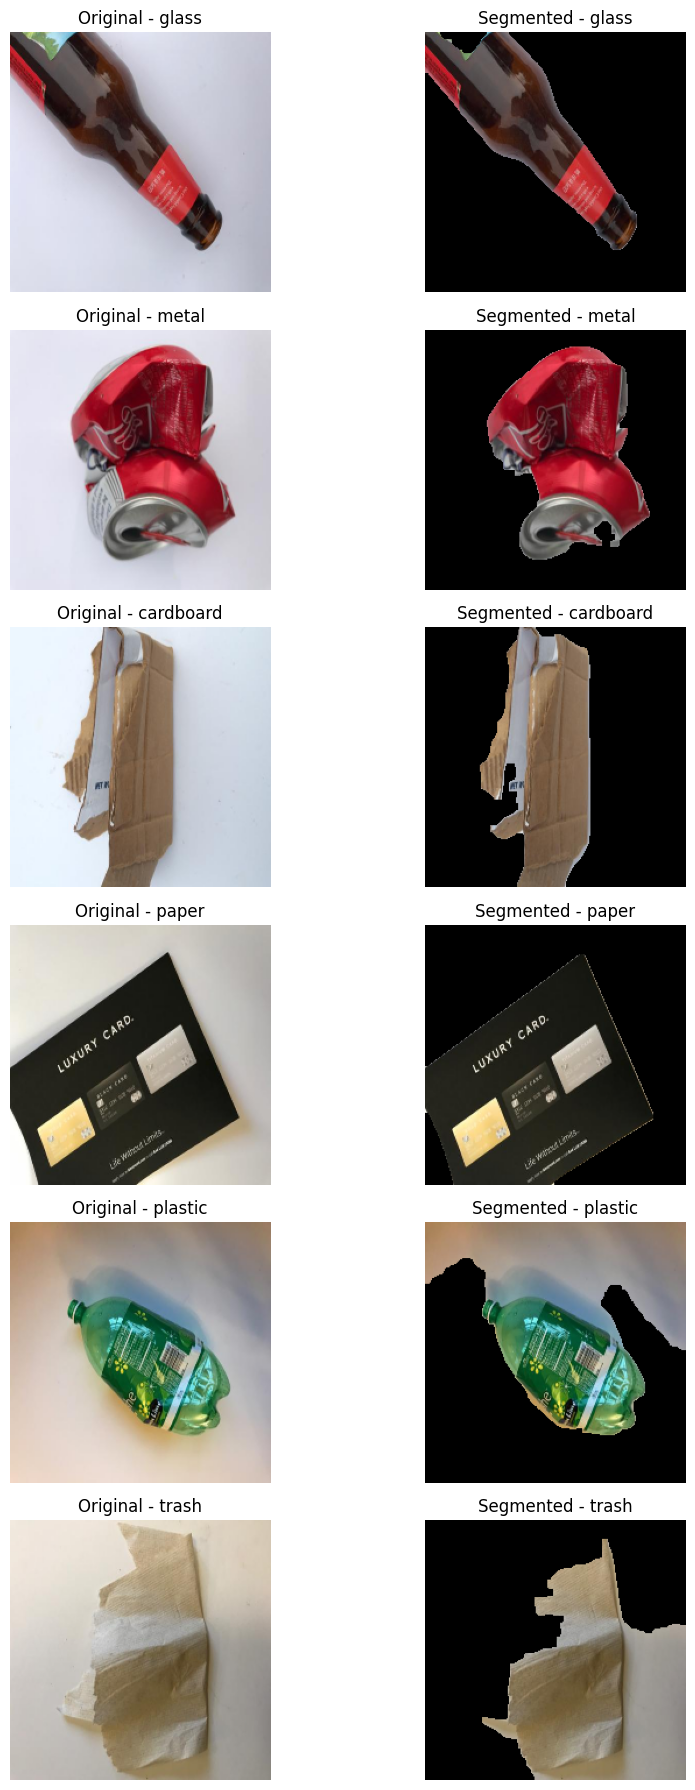

In [46]:
# ============================================================
# 7. VISUALIZE SEGMENTATION EXAMPLES
# ============================================================

plt.figure(figsize=(10, 18))

for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(img, (224, 224))
    segmented = apply_segmentation_largest_contour(img)

    plt.subplot(len(classes), 2, 2*i + 1)
    plt.imshow(resized)
    plt.title(f"Original - {cls}")
    plt.axis("off")

    plt.subplot(len(classes), 2, 2*i + 2)
    plt.imshow(segmented)
    plt.title(f"Segmented - {cls}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# 8. PREPROCESSING FUNCTION FOR SEGMENTED IMAGES
# ============================================================

def segmentation_preprocess(img):
    img = img.astype(np.uint8)
    img = apply_segmentation_largest_contour(img)
    img = preprocess_input(img.astype(np.float32))
    return img

In [48]:
# ============================================================
# 9. CREATE DATA GENERATORS
# Original Images vs Segmented Images
# ============================================================

img_size = (224, 224)
batch_size = 32

# Original images generator
original_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

original_train = original_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

original_val = original_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

# Segmented images generator
segmented_datagen = ImageDataGenerator(
    preprocessing_function=segmentation_preprocess,
    validation_split=0.2
)

segmented_train = segmented_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

segmented_val = segmented_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Class indices:", original_train.class_indices)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [49]:
# ============================================================
# 10. BUILD CNN CLASSIFIER USING MobileNetV2
# ============================================================

def build_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dense(6, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [50]:
# ============================================================
# 11. TRAIN MODEL ON ORIGINAL IMAGES
# ============================================================

original_model = build_model()

original_history = original_model.fit(
    original_train,
    validation_data=original_val,
    epochs=10
)

2026-05-29 22:54:37.577694: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-29 22:54:37.580118: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/10


2026-05-29 22:54:48.022213: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 154140672 exceeds 10% of free system memory.
2026-05-29 22:54:48.144731: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 156905472 exceeds 10% of free system memory.


 1/64 ━━━━━━━━━━━━━━━━━━━━ 9:04 9s/step - accuracy: 0.1250 - loss: 2.0452

2026-05-29 22:54:49.003905: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 154140672 exceeds 10% of free system memory.
2026-05-29 22:54:49.113761: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 156905472 exceeds 10% of free system memory.


 2/64 ━━━━━━━━━━━━━━━━━━━━ 1:01 992ms/step - accuracy: 0.1484 - loss: 2.0632

2026-05-29 22:54:50.003085: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 154140672 exceeds 10% of free system memory.


64/64 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.6838 - loss: 0.8515 - val_accuracy: 0.7296 - val_loss: 0.7196
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 907ms/step - accuracy: 0.8424 - loss: 0.4234 - val_accuracy: 0.7495 - val_loss: 0.7110
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 924ms/step - accuracy: 0.8691 - loss: 0.3532 - val_accuracy: 0.7575 - val_loss: 0.6853
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 896ms/step - accuracy: 0.8992 - loss: 0.2703 - val_accuracy: 0.7575 - val_loss: 0.6243
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 911ms/step - accuracy: 0.9214 - loss: 0.2183 - val_accuracy: 0.7634 - val_loss: 0.6733
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 933ms/step - accuracy: 0.9318 - loss: 0.1869 - val_accuracy: 0.7734 - val_loss: 0.7420
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 893ms/step - accuracy: 0.9486 - loss: 0.1554 - val_accuracy: 0.7893 - val_loss: 0.7356
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 916ms/step - accuracy: 0.9511 - loss: 0.1400 - val_accuracy: 0.7753 -

In [52]:
# ============================================================
# 12. TRAIN MODEL ON SEGMENTED IMAGES
# ============================================================

segmented_model = build_model()

segmented_history = segmented_model.fit(
    segmented_train,
    validation_data=segmented_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 967ms/step - accuracy: 0.5840 - loss: 1.1316 - val_accuracy: 0.6402 - val_loss: 0.9801
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 905ms/step - accuracy: 0.7317 - loss: 0.7075 - val_accuracy: 0.6740 - val_loss: 0.8976
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 939ms/step - accuracy: 0.7782 - loss: 0.6091 - val_accuracy: 0.6740 - val_loss: 0.8681
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 914ms/step - accuracy: 0.8157 - loss: 0.5077 - val_accuracy: 0.7018 - val_loss: 0.8267
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8429 - loss: 0.4329 - val_accuracy: 0.6680 - val_loss: 0.8996
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 952ms/step - accuracy: 0.8538 - loss: 0.4017 - val_accuracy: 0.6958 - val_loss: 0.8367
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.8602 - loss: 0.3594 - val_accuracy: 0.6998 - val_loss: 0.8291
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.8977 - loss: 0.3018 - val_accuracy: 0.7

In [53]:
# ============================================================
# 13. COMPARE ACCURACY RESULTS
# ============================================================

original_acc = original_history.history["val_accuracy"][-1]
segmented_acc = segmented_history.history["val_accuracy"][-1]

print("Original Images Validation Accuracy:", original_acc)
print("Segmented Images Validation Accuracy:", segmented_acc)

Original Images Validation Accuracy: 0.7693836688995361
Segmented Images Validation Accuracy: 0.6858847141265869


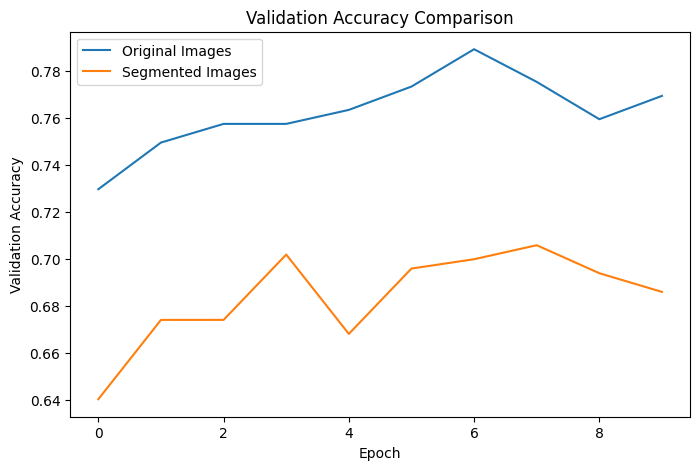

In [54]:
# ============================================================
# 14. PLOT VALIDATION ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(original_history.history["val_accuracy"], label="Original Images")
plt.plot(segmented_history.history["val_accuracy"], label="Segmented Images")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

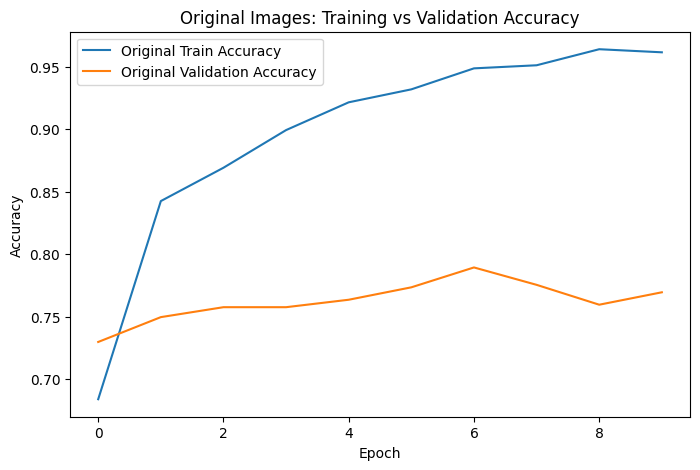

In [55]:
# ============================================================
# 15. PLOT TRAINING VS VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(original_history.history["accuracy"], label="Original Train Accuracy")
plt.plot(original_history.history["val_accuracy"], label="Original Validation Accuracy")

plt.title("Original Images: Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

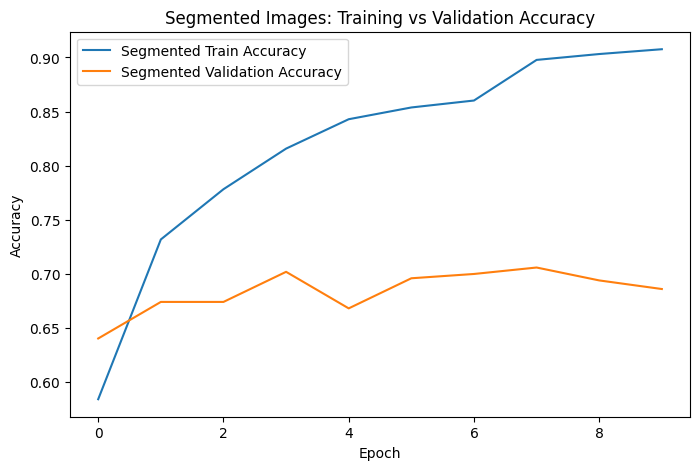

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(segmented_history.history["accuracy"], label="Segmented Train Accuracy")
plt.plot(segmented_history.history["val_accuracy"], label="Segmented Validation Accuracy")

plt.title("Segmented Images: Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()